In [1]:
!pip install pytorch-forecasting lightning optuna twilio folium streamlit-folium matplotlib seaborn plotly scikit-learn requests tqdm rich -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 128.6 MB/s eta 0:00:00
✅ All dependencies installed


In [2]:
import os, warnings, json, time, math, requests
from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm

try:
    from rich.console import Console
    from rich.table import Table
    console = Console()
except:
    class DummyConsole:
        def print(self, x): print(x)
    console = DummyConsole()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import torch
import torch.nn as nn

# Lightning (new import style)
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import (
    TimeSeriesDataSet, TemporalFusionTransformer, Baseline
)
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# ─── DEVICE SETUP (FIXED FOR COLAB) ─────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ─── GLOBAL CONFIG ──────────────────────────────────────────
CFG = {
    # Training
    "seed":           42,
    "device":         DEVICE,     # auto-detect GPU
    "max_epochs":     60,
    "batch_size":     64,
    "lr":             3e-3,
    "gradient_clip":  0.1,

    # TFT architecture
    "encoder_length": 90,
    "pred_length":    21,
    "hidden_size":    128,
    "attn_heads":     4,
    "dropout":        0.15,
    "hidden_cont":    32,
    "quantiles":      [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98],

    # Data
    "n_farms":        60,
    "n_days":         730,
    "start_date":     "2022-01-01",
    "conformal_alpha": 0.1,
    "stress_threshold": 0.35,

    # Paths (FIXED for Colab)
    "output_dir":     "/content/crop_ews",
    "model_dir":      "/content/crop_ews/models",
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)
Path(CFG["model_dir"]).mkdir(parents=True, exist_ok=True)

console.print("[bold green]✅ Config loaded (Colab Ready)[/bold green]")
console.print(
    f"Device: [cyan]{CFG['device']}[/cyan] | "
    f"Farms: {CFG['n_farms']} | Days: {CFG['n_days']} | "
    f"Encoder: {CFG['encoder_length']}d → Pred: {CFG['pred_length']}d"
)

✅ Config loaded (Colab Ready)

Device: cuda | Farms: 60 | Days: 730 | Encoder: 90d → Pred: 21d

In [3]:
# Soil water-holding capacities and stress sensitivities
SOIL_PROFILES = {
    "Sandy":    {"whc": 0.12, "stress_sens": 1.4, "color": "#F4A460"},
    "Clay":     {"whc": 0.38, "stress_sens": 0.7, "color": "#8B4513"},
    "Loam":     {"whc": 0.28, "stress_sens": 0.9, "color": "#6B8E23"},
    "Silty":    {"whc": 0.32, "stress_sens": 0.85, "color": "#BDB76B"},
    "Laterite": {"whc": 0.18, "stress_sens": 1.2, "color": "#CD853F"},
}

# Agro-ecological zones with crop calendars and climate params
AGRO_ZONES = {
    "Tropical_Wet":       {"lat_range": (8,  15),  "lon_range": (74, 80),  "rain_mu": 6.5, "temp_mu": 28, "crop": "Rice"},
    "Tropical_Dry":       {"lat_range": (15, 22),  "lon_range": (73, 79),  "rain_mu": 2.0, "temp_mu": 32, "crop": "Sorghum"},
    "Semi_Arid":          {"lat_range": (22, 28),  "lon_range": (70, 77),  "rain_mu": 1.0, "temp_mu": 30, "crop": "Millet"},
    "Sub_Tropical_Humid": {"lat_range": (25, 30),  "lon_range": (80, 88),  "rain_mu": 4.5, "temp_mu": 25, "crop": "Wheat"},
    "Highland":           {"lat_range": (28, 35),  "lon_range": (76, 85),  "rain_mu": 3.0, "temp_mu": 18, "crop": "Barley"},
}

def generate_farm_locations(n_farms: int, seed: int = 42) -> pd.DataFrame:
    """Generate diverse farm locations across agro-ecological zones."""
    rng = np.random.default_rng(seed)
    farms = []
    soil_types = list(SOIL_PROFILES.keys())
    zone_names = list(AGRO_ZONES.keys())

    for i in range(n_farms):
        zone_name = zone_names[i % len(zone_names)]
        zone = AGRO_ZONES[zone_name]
        lat = rng.uniform(*zone["lat_range"])
        lon = rng.uniform(*zone["lon_range"])
        soil = rng.choice(soil_types)
        elevation = rng.uniform(50, 2000) if "Highland" in zone_name else rng.uniform(10, 500)

        farms.append({
            "farm_id":       f"FARM_{i:03d}",
            "latitude":      round(lat, 4),
            "longitude":     round(lon, 4),
            "elevation":     round(elevation, 1),
            "soil_type":     soil,
            "agro_zone":     zone_name,
            "crop_type":     zone["crop"],
            "farm_area_ha":  round(rng.uniform(0.5, 10.0), 2),
            "rain_mu":       zone["rain_mu"],
            "temp_mu":       zone["temp_mu"],
            "whc":           SOIL_PROFILES[soil]["whc"],
            "stress_sens":   SOIL_PROFILES[soil]["stress_sens"],
        })

    df = pd.DataFrame(farms)
    console.print(f"[green]✅ {n_farms} farms generated across {len(zone_names)} agro-zones[/green]")
    return df

farm_df = generate_farm_locations(CFG["n_farms"], CFG["seed"])

table = Table(title="Farm Distribution by Zone")
table.add_column("Zone", style="cyan")
table.add_column("Farms", justify="right")
table.add_column("Crop", style="yellow")
table.add_column("Dominant Soil")

for zone in AGRO_ZONES:
    sub = farm_df[farm_df["agro_zone"] == zone]
    dominant_soil = sub["soil_type"].mode()[0] if len(sub) > 0 else "N/A"
    table.add_row(zone, str(len(sub)), AGRO_ZONES[zone]["crop"], dominant_soil)

console.print(table)

✅ 60 farms generated across 5 agro-zones

               Farm Distribution by Zone                
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Zone               ┃ Farms ┃ Crop    ┃ Dominant Soil ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Tropical_Wet       │    12 │ Rice    │ Loam          │
│ Tropical_Dry       │    12 │ Sorghum │ Clay          │
│ Semi_Arid          │    12 │ Millet  │ Loam          │
│ Sub_Tropical_Humid │    12 │ Wheat   │ Clay          │
│ Highland           │    12 │ Barley  │ Sandy         │
└────────────────────┴───────┴─────────┴───────────────┘

In [4]:
NASA_POWER_BASE = "https://power.larc.nasa.gov/api/temporal/daily/point"
NASA_PARAMS = "T2M,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN,T2MDEW"

def fetch_nasa_power(lat: float, lon: float,
                     start: str, end: str,
                     retries: int = 3) -> Optional[pd.DataFrame]:
    """
    Fetch meteorological data from NASA POWER API (completely free).
    Parameters: Temperature, Precipitation, Humidity, Wind, Solar Radiation, Dew Point
    """
    url = (
        f"{NASA_POWER_BASE}?"
        f"parameters={NASA_PARAMS}&community=AG"
        f"&longitude={lon}&latitude={lat}"
        f"&start={start.replace('-','')}&end={end.replace('-','')}"
        f"&format=JSON"
    )
    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=30)
            if resp.status_code == 200:
                data = resp.json()
                params_data = data["properties"]["parameter"]
                df = pd.DataFrame(params_data)
                df.index = pd.to_datetime(df.index, format="%Y%m%d")
                df.index.name = "date"
                df.columns = ["temp_c", "precip_mm", "humidity_pct",
                              "wind_ms", "solar_kwh", "dewpoint_c"]
                df = df.replace(-999.0, np.nan).interpolate()
                return df.reset_index()
        except Exception as e:
            if attempt == retries - 1:
                console.print(f"[red]NASA POWER failed for ({lat},{lon}): {e}[/red]")
    return None


def generate_synthetic_weather(lat: float, lon: float,
                                rain_mu: float, temp_mu: float,
                                n_days: int, start_date: str,
                                seed: int = 42) -> pd.DataFrame:
    """
    Fallback: Physics-inspired synthetic weather generator.
    Used on Kaggle where live API calls are rate-limited.
    Incorporates: seasonal cycles, ENSO-like anomalies, wet/dry spells.
    """
    rng = np.random.default_rng(seed + int(lat * 1000))
    dates = pd.date_range(start_date, periods=n_days, freq="D")
    t = np.arange(n_days)

    # Seasonal temperature cycle
    phase_shift = (lat - 15) * 0.05  # latitude adjusts season timing
    temp_seasonal = temp_mu + 6 * np.sin(2 * np.pi * (t - 90 + phase_shift * 10) / 365)
    temp = temp_seasonal + rng.normal(0, 1.5, n_days)

    # Monsoon-like rainfall (log-normal during wet season)
    rain = np.zeros(n_days)
    for d in range(n_days):
        doy = dates[d].dayofyear
        # Wet season: June-September (doy 152-273)
        wet_prob = 0.5 * (np.sin(2 * np.pi * (doy - 60) / 365) + 1)
        wet_prob = np.clip(wet_prob * (rain_mu / 3.0), 0.05, 0.75)
        if rng.random() < wet_prob:
            rain[d] = rng.exponential(rain_mu * 2)
        # Dry spell clusters
        if d > 0 and rain[d-1] == 0 and rng.random() < 0.7:
            rain[d] = 0

    # Humidity correlated with rainfall
    humidity = 40 + 35 * (rain / (rain.max() + 1e-6)) + rng.normal(0, 5, n_days)
    humidity = np.clip(humidity, 20, 100)

    # Solar radiation (anti-correlated with clouds/rain)
    solar = 5.5 - 2 * (rain / (rain.max() + 1e-6)) + \
            1.5 * np.sin(2 * np.pi * t / 365) + rng.normal(0, 0.3, n_days)
    solar = np.clip(solar, 0.5, 9.0)

    wind = np.clip(2.5 + rng.exponential(1.0, n_days), 0.5, 12.0)
    dewpoint = temp - (100 - humidity) / 5

    return pd.DataFrame({
        "date":          dates,
        "temp_c":        temp,
        "precip_mm":     rain,
        "humidity_pct":  humidity,
        "wind_ms":       wind,
        "solar_kwh":     solar,
        "dewpoint_c":    dewpoint,
    })


def get_weather_for_farm(farm_row: pd.Series, use_api: bool = False) -> pd.DataFrame:
    """Fetch real or synthetic weather for a single farm."""
    if use_api:
        end_date = (datetime.strptime(CFG["start_date"], "%Y-%m-%d") +
                    timedelta(days=CFG["n_days"] - 1)).strftime("%Y-%m-%d")
        df = fetch_nasa_power(farm_row["latitude"], farm_row["longitude"],
                              CFG["start_date"], end_date)
        if df is not None:
            return df

    # Fallback to synthetic
    return generate_synthetic_weather(
        lat=farm_row["latitude"],
        lon=farm_row["longitude"],
        rain_mu=farm_row["rain_mu"],
        temp_mu=farm_row["temp_mu"],
        n_days=CFG["n_days"],
        start_date=CFG["start_date"],
        seed=CFG["seed"] + hash(farm_row["farm_id"]) % 10000,
    )

# Test on one farm
sample_weather = get_weather_for_farm(farm_df.iloc[0], use_api=False)
console.print(f"[green]✅ Weather shape: {sample_weather.shape}[/green]")
console.print(sample_weather.head(3))

✅ Weather shape: (730, 7)

date     temp_c  precip_mm  humidity_pct   wind_ms  solar_kwh  \
0 2022-01-01  23.787550        0.0     40.044233  3.025388   5.775913   
1 2022-01-02  22.081378        0.0     36.993346  3.004036   5.302238   
2 2022-01-03  22.166494        0.0     37.621680  2.889789   5.535567   

   dewpoint_c  
0   11.796397  
1    9.480047  
2    9.690830

In [ ]:

def simulate_ndvi(weather_df: pd.DataFrame,
                  farm_row: pd.Series,
                  seed: int = 42) -> np.ndarray:
    """
    Biophysically-inspired NDVI simulation.
    Incorporates:
    - Seasonal growing cycle (double-Gaussian for kharif+rabi crops)
    - Weather-NDVI coupling (VPD, rain stress, heat stress)
    - Soil water balance (bucket model)
    - Random drought/pest stress events
    - Spatial noise
    """
    rng = np.random.default_rng(seed)
    n = len(weather_df)
    temp = weather_df["temp_c"].values
    rain = weather_df["precip_mm"].values
    solar = weather_df["solar_kwh"].values
    humidity = weather_df["humidity_pct"].values
    t = np.arange(n)

    # ── Seasonal base NDVI (two crop seasons per year) ──────────
    def gauss_season(center, width, amplitude):
        return amplitude * np.exp(-0.5 * ((t % 365 - center) / width) ** 2)

    kharif  = gauss_season(195, 45, 0.68)   # June-Oct (monsoon crop)
    rabi    = gauss_season(350, 50, 0.55)   # Nov-Mar (winter crop)
    base_ndvi = 0.18 + kharif + rabi         # bare soil base

    # ── Soil water balance (simple bucket model) ─────────────────
    whc = farm_row["whc"]                    # from soil profile
    et0 = 0.0023 * solar * (temp + 17.8) * np.sqrt(np.abs(temp - dewpoint_approx(humidity, temp)))
    et0 = np.clip(et0, 0.1, 8.0)
    bucket = 0.5 * whc                       # initial soil moisture
    soil_moisture = np.zeros(n)
    for d in range(n):
        bucket = min(bucket + rain[d] * 0.8, whc)
        bucket = max(bucket - et0[d] * 0.001, 0.0)
        soil_moisture[d] = bucket

    # ── Weather-NDVI stress factors ───────────────────────────────
    # VPD stress (heat × low humidity)
    vpd = np.clip((1 - humidity / 100) * (temp - 15) * 0.05, 0, 1)
    vpd_stress = 1 - 0.4 * vpd

    # Drought stress (soil moisture depleted)
    drought_stress = np.clip(soil_moisture / (whc * 0.4), 0, 1) ** farm_row["stress_sens"]

    # Heat stress (temp > 38°C)
    heat_stress = 1 - 0.6 * np.clip((temp - 38) / 10, 0, 1)

    stress = vpd_stress * drought_stress * heat_stress

    # ── Discrete stress events (drought/pest/flood) ───────────────
    events = np.ones(n)
    n_events = rng.integers(2, 6)
    for _ in range(n_events):
        ev_start = rng.integers(60, n - 60)
        ev_len   = rng.integers(7, 28)
        severity = rng.uniform(0.3, 0.85)
        recovery_rate = 0.03 * (1 + rng.uniform(-0.3, 0.3))
        for d in range(ev_len):
            if ev_start + d < n:
                events[ev_start + d] *= severity
        # Exponential recovery
        for d in range(ev_len, ev_len + 30):
            if ev_start + d < n:
                events[ev_start + d] = min(1.0,
                    events[ev_start + d - 1] + recovery_rate)

    # ── Final NDVI ────────────────────────────────────────────────
    ndvi = base_ndvi * stress * events
    ndvi += rng.normal(0, 0.012, n)          # sensor noise
    ndvi = np.clip(ndvi, 0.05, 0.95)

    # Sentinel-2 revisit: 5-day composites with gaps → daily interpolated
    sentinel_mask = np.zeros(n, dtype=bool)
    sentinel_mask[::5] = True
    sentinel_obs = np.where(sentinel_mask, ndvi, np.nan)
    # Interpolate to daily
    s = pd.Series(sentinel_obs).interpolate(method="cubicspline")
    ndvi_daily = s.fillna(method="ffill").fillna(method="bfill").values

    return ndvi_daily


def dewpoint_approx(humidity: np.ndarray, temp: np.ndarray) -> np.ndarray:
    """Magnus formula approximation for dewpoint."""
    a, b = 17.27, 237.7
    alpha = ((a * temp) / (b + temp)) + np.log(humidity / 100.0)
    return (b * alpha) / (a - alpha)



console.print("[green]✅ NDVI simulator ready | GEE snippet printed above[/green]")



# ============================================================
# PRODUCTION: Replace simulate_ndvi() with this GEE function
# Requires: pip install earthengine-api
#           ee.Authenticate() once in browser
# ============================================================
import ee
ee.Initialize(project='your-gcp-project')

def gee_fetch_ndvi(lat, lon, start_date, end_date, buffer_m=500):
    point = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(point)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
            .map(lambda img: img.normalizedDifference(["B8", "B4"])
                               .rename("NDVI")
                               .set("date", img.date().format("YYYY-MM-dd"))))
    def extract(img):
        val = img.reduceRegion(ee.Reducer.mean(), point, 10).get("NDVI")
        return ee.Feature(None, {"date": img.get("date"

✅ NDVI simulator ready | GEE snippet printed above

In [6]:
def build_dataset(farm_df: pd.DataFrame,
                  use_api: bool = False) -> pd.DataFrame:
    """
    Assembles complete training DataFrame for TFT.
    For each farm: weather + NDVI + derived features.
    """
    all_dfs = []

    for idx, farm_row in tqdm(farm_df.iterrows(),
                               total=len(farm_df),
                               desc="Building dataset"):
        # ── Weather ──────────────────────────────────────────────
        wx = get_weather_for_farm(farm_row, use_api=use_api)

        # ── NDVI ─────────────────────────────────────────────────
        ndvi = simulate_ndvi(wx, farm_row,
                             seed=CFG["seed"] + idx * 37)
        wx["ndvi"] = ndvi

        # ── Static features (repeated per row) ───────────────────
        wx["farm_id"]    = farm_row["farm_id"]
        wx["soil_type"]  = farm_row["soil_type"]
        wx["agro_zone"]  = farm_row["agro_zone"]
        wx["crop_type"]  = farm_row["crop_type"]
        wx["latitude"]   = farm_row["latitude"]
        wx["longitude"]  = farm_row["longitude"]
        wx["elevation"]  = farm_row["elevation"]
        wx["whc"]        = farm_row["whc"]
        wx["stress_sens"]= farm_row["stress_sens"]
        wx["farm_area"]  = farm_row["farm_area_ha"]

        all_dfs.append(wx)

    df = pd.concat(all_dfs, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["farm_id", "date"]).reset_index(drop=True)

    # ── Integer time index per farm ───────────────────────────────
    df["time_idx"] = df.groupby("farm_id").cumcount()

    console.print(f"[green]✅ Dataset built: {df.shape}[/green]")
    return df

raw_df = build_dataset(farm_df, use_api=False)
raw_df.head(3)

Building dataset: 100%|██████████| 60/60 [00:01<00:00, 35.27it/s]


✅ Dataset built: (43800, 19)

,date,temp_c,precip_mm,humidity_pct,wind_ms,solar_kwh,dewpoint_c,ndvi,farm_id,soil_type,agro_zone,crop_type,latitude,longitude,elevation,whc,stress_sens,farm_area,time_idx
0,2022-01-01,23.787550,0.0,40.044233,3.025388,5.775913,11.796397,0.157289,FARM_000,Loam,Tropical_Wet,Rice,13.4177,76.6333,351.7,0.28,0.9,1.39,0
1,2022-01-02,22.081378,0.0,36.993346,3.004036,5.302238,9.480047,0.166800,FARM_000,Loam,Tropical_Wet,Rice,13.4177,76.6333,351.7,0.28,0.9,1.39,1
2,2022-01-03,22.166494,0.0,37.621680,2.889789,5.535567,9.690830,0.171716,FARM_000,Loam,Tropical_Wet,Rice,13.4177,76.6333,351.7,0.28,0.9,1.39,2


In [7]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Comprehensive feature engineering:
    - Rolling statistics (7, 14, 30-day)
    - Lag features
    - Vapour Pressure Deficit (VPD)
    - Standardised Precipitation Index (SPI proxy)
    - Growing Degree Days (GDD)
    - NDVI derivatives (rate of change)
    - Day of year cyclical encoding
    - Crop calendar features
    """
    df = df.copy().sort_values(["farm_id", "date"])

    # ── Cyclical time encoding ─────────────────────────────────────
    df["doy"]       = df["date"].dt.dayofyear
    df["doy_sin"]   = np.sin(2 * np.pi * df["doy"] / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * df["doy"] / 365)
    df["month_sin"] = np.sin(2 * np.pi * df["date"].dt.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["date"].dt.month / 12)

    # ── Rolling weather stats ──────────────────────────────────────
    for win in [7, 14, 30]:
        grp = df.groupby("farm_id")
        for col, agg in [
            ("precip_mm",   ["sum", "mean"]),
            ("temp_c",      ["mean", "max"]),
            ("humidity_pct",["mean"]),
            ("solar_kwh",   ["mean"]),
        ]:
            for a in agg:
                df[f"{col}_roll{win}_{a}"] = (
                    grp[col]
                    .transform(lambda x: x.rolling(win, min_periods=1).__getattribute__(a)())
                )

    # ── NDVI rolling ───────────────────────────────────────────────
    grp = df.groupby("farm_id")
    for win in [7, 14]:
        df[f"ndvi_roll{win}_mean"] = grp["ndvi"].transform(
            lambda x: x.rolling(win, min_periods=1).mean())
        df[f"ndvi_roll{win}_std"] = grp["ndvi"].transform(
            lambda x: x.rolling(win, min_periods=1).std().fillna(0))

    # ── NDVI rate of change (momentum) ────────────────────────────
    df["ndvi_diff1"] = grp["ndvi"].transform(lambda x: x.diff(1).fillna(0))
    df["ndvi_diff7"] = grp["ndvi"].transform(lambda x: x.diff(7).fillna(0))

    # ── Lag features ───────────────────────────────────────────────
    for lag in [1, 3, 7, 14]:
        df[f"ndvi_lag{lag}"]   = grp["ndvi"].transform(lambda x: x.shift(lag).fillna(method="bfill"))
        df[f"precip_lag{lag}"] = grp["precip_mm"].transform(lambda x: x.shift(lag).fillna(0))
        df[f"temp_lag{lag}"]   = grp["temp_c"].transform(lambda x: x.shift(lag).fillna(method="bfill"))

    # ── Vapour Pressure Deficit ────────────────────────────────────
    def sat_vapor_pressure(T):
        return 0.6108 * np.exp(17.27 * T / (T + 237.3))  # kPa
    df["es"]  = sat_vapor_pressure(df["temp_c"])
    df["ea"]  = df["es"] * df["humidity_pct"] / 100
    df["vpd"] = np.clip(df["es"] - df["ea"], 0, 5)

    # ── SPI-like drought index (30-day rain anomaly) ───────────────
    rain_mu  = df.groupby("farm_id")["precip_mm"].transform("mean")
    rain_std = df.groupby("farm_id")["precip_mm"].transform("std").replace(0, 1)
    df["spi30"] = (df["precip_mm_roll30_mean"] - rain_mu) / rain_std
    df["spi30"] = df["spi30"].clip(-3, 3)

    # ── Growing Degree Days (base 10°C) ───────────────────────────
    df["gdd"]      = np.maximum(df["temp_c"] - 10, 0)
    df["gdd_cum"]  = grp["gdd"].transform(lambda x: x.cumsum() % 2000)  # reset yearly

    # ── Heat stress indicator ──────────────────────────────────────
    df["heat_stress"]    = (df["temp_c"] > 38).astype(float)
    df["heat_stress_7d"] = grp["heat_stress"].transform(
        lambda x: x.rolling(7, min_periods=1).sum())

    # ── Soil water stress proxy ────────────────────────────────────
    df["water_stress"] = (1 - np.clip(df["precip_mm_roll14_sum"] /
                                      (df["whc"] * 100 + 1e-6), 0, 1))

    # ── Crop calendar: days since planting (simplified) ───────────
    df["days_in_season"] = (df["doy"] % 180).astype(float)

    # Fill any remaining NaN
    df = df.fillna(0)
    df = df.replace([np.inf, -np.inf], 0)

    console.print(f"[green]✅ Features engineered: {df.shape[1]} columns[/green]")
    return df

feat_df = engineer_features(raw_df)
feature_cols = [c for c in feat_df.columns if c not in
                ["date", "farm_id", "ndvi", "time_idx",
                 "soil_type", "agro_zone", "crop_type"]]
console.print(f"Feature count: [cyan]{len(feature_cols)}[/cyan]")
feat_df.head(2)

✅ Features engineered: 70 columns

Feature count: 63

,date,temp_c,precip_mm,humidity_pct,wind_ms,solar_kwh,dewpoint_c,ndvi,farm_id,soil_type,...,es,ea,vpd,spi30,gdd,gdd_cum,heat_stress,heat_stress_7d,water_stress,days_in_season
0,2022-01-01,23.787550,0.0,40.044233,3.025388,5.775913,11.796397,0.157289,FARM_000,Loam,...,2.946079,1.179735,1.766344,-0.452744,13.787550,13.787550,0.0,0.0,1.0,1.0
1,2022-01-02,22.081378,0.0,36.993346,3.004036,5.302238,9.480047,0.166800,FARM_000,Loam,...,2.657074,0.982941,1.674133,-0.452744,12.081378,25.868928,0.0,0.0,1.0,2.0


In [17]:
# Step 1: Hard-clip ndvi to safe range for softplus
# softplus normalizer breaks on values == 0.0 exactly
NDVI_EPS = 0.01
for df_ in [feat_df, train_data, val_data]:
    df_["ndvi"] = df_["ndvi"].clip(lower=NDVI_EPS, upper=0.99)
    df_["ndvi"] = df_["ndvi"].fillna(NDVI_EPS)
    # Also clip all UNKNOWN_REALS that are ndvi-derived
    for col in ["ndvi_roll7_mean","ndvi_roll14_mean",
                "ndvi_lag1","ndvi_lag3","ndvi_lag7","ndvi_lag14"]:
        if col in df_.columns:
            df_[col] = df_[col].clip(lower=0.0, upper=1.0).fillna(NDVI_EPS)

# Step 2: Paranoid per-group NaN check on val_data
# PTF windows can expose NaNs invisible to column-level .isna()
problem_rows = val_data[val_data["ndvi"].isna() |
                         np.isinf(val_data["ndvi"])]
console.print(f"Remaining bad ndvi rows in val: {len(problem_rows)}")

# Nuclear option — fill any surviving NaN per farm with group median
val_data["ndvi"] = (
    val_data.groupby("farm_id")["ndvi"]
    .transform(lambda x: x.fillna(x.median()).fillna(NDVI_EPS))
)
train_data["ndvi"] = (
    train_data.groupby("farm_id")["ndvi"]
    .transform(lambda x: x.fillna(x.median()).fillna(NDVI_EPS))
)

# Step 3: TimeSeriesDataSet with EncoderNormalizer
# EncoderNormalizer normalizes per-window on the encoder mean/std
# — avoids softplus blowing up on edge values
from pytorch_forecasting.data import EncoderNormalizer

training = TimeSeriesDataSet(
    train_data,
    time_idx              = "time_idx",
    target                = "ndvi",
    group_ids             = ["farm_id"],
    min_encoder_length    = CFG["encoder_length"] // 2,
    max_encoder_length    = CFG["encoder_length"],
    min_prediction_length = CFG["pred_length"],
    max_prediction_length = CFG["pred_length"],
    static_categoricals   = STATIC_CATS,
    static_reals          = STATIC_REALS,
    time_varying_known_categoricals   = [],
    time_varying_known_reals          = KNOWN_REALS,
    time_varying_unknown_categoricals = [],
    time_varying_unknown_reals        = UNKNOWN_REALS + ["ndvi"],
    target_normalizer = EncoderNormalizer(
        method="standard",           # z-score per encoder window
        center=True,
        transformation=None,         # no softplus — avoids log(0) NaN
    ),
    categorical_encoders = {
        col: NaNLabelEncoder(add_nan=True) for col in STATIC_CATS
    },
    add_relative_time_idx = True,
    add_target_scales     = True,
    add_encoder_length    = True,
    allow_missing_timesteps = True,
)

validation = TimeSeriesDataSet.from_dataset(
    training, val_data, predict=True, stop_randomization=True
)

train_dl = training.to_dataloader(
    train=True, batch_size=CFG["batch_size"],
    num_workers=2, pin_memory=True
)
val_dl = validation.to_dataloader(
    train=False, batch_size=CFG["batch_size"] * 2,
    num_workers=2
)

console.print(f"[green]✅ TimeSeriesDataSet ready[/green]")
console.print(f"  Train: {len(training)} | Val: {len(validation)}")
console.print(
    f"  Encoder: {training.get_parameters()['max_encoder_length']}d → "
    f"Pred: {training.get_parameters()['max_prediction_length']}d"
)

Remaining bad ndvi rows in val: 0

✅ TimeSeriesDataSet ready

Train: 36000 | Val: 60

Encoder: 90d → Pred: 21d

In [18]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate        = CFG["lr"],
    hidden_size          = CFG["hidden_size"],
    attention_head_size  = CFG["attn_heads"],
    dropout              = CFG["dropout"],
    hidden_continuous_size = CFG["hidden_cont"],
    loss                 = QuantileLoss(quantiles=CFG["quantiles"]),
    output_size          = len(CFG["quantiles"]),
    optimizer            = "Adam",
    reduce_on_plateau_patience = 5,
    log_interval         = 50,
    log_gradient_flow    = False,
)

n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
console.print(f"[bold cyan]TFT Parameters: {n_params:,}[/bold cyan]")
console.print(f"Architecture: hidden={CFG['hidden_size']} | "
              f"heads={CFG['attn_heads']} | "
              f"quantiles={CFG['quantiles']}")

# ── Callbacks ─────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss", patience=8,
    verbose=True, mode="min"
)
checkpoint = ModelCheckpoint(
    dirpath       = CFG["model_dir"],
    filename      = "tft_crop_ews_{epoch:02d}_{val_loss:.4f}",
    monitor       = "val_loss",
    save_top_k    = 1,
    mode          = "min",
)
lr_monitor = LearningRateMonitor(logging_interval="step")
csv_logger = CSVLogger(save_dir=CFG["output_dir"], name="tft_logs")

# ── Trainer ────────────────────────────────────────────────────
trainer = pl.Trainer(
    max_epochs            = CFG["max_epochs"],
    accelerator           = CFG["device"],       # "gpu" on Kaggle T4, "cpu" locally
    devices               = 1,
    gradient_clip_val     = CFG["gradient_clip"],
    callbacks             = [early_stop, checkpoint, lr_monitor],
    logger                = csv_logger,
    enable_progress_bar   = True,
    log_every_n_steps     = 10,
    precision             = "16-mixed"           # FP16 for T4 speed boost
    if CFG["device"] == "gpu" else 32,
)

console.print("\n[bold yellow]🚀 Starting TFT Training...[/bold yellow]")
trainer.fit(tft, train_dataloaders=train_dl, val_dataloaders=val_dl)

# ── Load best model ────────────────────────────────────────────
best_model_path = checkpoint.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
best_tft.eval()
console.print(f"\n[bold green]✅ Best model: {best_model_path}[/bold green]")
console.print(f"Best val_loss: {checkpoint.best_model_score:.4f}")

TFT Parameters: 1,559,393

Architecture: hidden=128 | heads=4 | quantiles=[0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


🚀 Starting TFT Training...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 1060                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 0.065
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.065
INFO: Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.056
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.056
INFO: Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.056
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.056
INFO: Monitored metric val_loss did not improve in the last 8 records. Best score: 0.056. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 8 records. Best score: 0.056. Signaling Trainer to stop.


✅ Best model: /content/crop_ews/models/tft_crop_ews_epoch=04_val_loss=0.0560.ckpt

Best val_loss: 0.0560

In [22]:
def move_batch_to_device(batch, device):
    """Recursively move all tensors in a nested batch to device."""
    if isinstance(batch, torch.Tensor):
        return batch.to(device)
    elif isinstance(batch, dict):
        return {k: move_batch_to_device(v, device) for k, v in batch.items()}
    elif isinstance(batch, (list, tuple)):
        moved = [move_batch_to_device(b, device) for b in batch]
        return type(batch)(moved)
    return batch  # non-tensor (str, int, etc.) — leave as-is


def run_conformal_calibration(model, val_dl, training):
    """Run inference on validation set and calibrate conformal predictor."""
    device = next(model.parameters()).device  # auto-detect: cpu or cuda:0
    console.print(f"Running conformal calibration on device: [cyan]{device}[/cyan]")

    model.eval()
    actuals, preds = [], []

    with torch.no_grad():
        for batch in val_dl:
            # ── Move entire batch to model device ─────────────
            x, y = batch
            x = move_batch_to_device(x, device)
            y = move_batch_to_device(y, device)

            out    = model(x)
            pred_q = out["prediction"].cpu().numpy()   # (B, horizon, Q)
            true   = y[0].cpu().numpy()                # (B, horizon)

            preds.append(pred_q)
            actuals.append(true)

    preds   = np.concatenate(preds,   axis=0)
    actuals = np.concatenate(actuals, axis=0)

    console.print(f"  Collected → preds: {preds.shape} | actuals: {actuals.shape}")

    q_lo  = preds[:, :, 0]   # 0.02 quantile
    q_hi  = preds[:, :, 6]   # 0.98 quantile
    q_med = preds[:, :, 3]   # 0.50 quantile

    cp = ConformalPredictor(alpha=CFG["conformal_alpha"])
    cp.calibrate(actuals, q_lo, q_hi)

    cp_preds = cp.predict(q_lo, q_hi, q_med)
    coverage = cp.evaluate_coverage(actuals, cp_preds)
    console.print(
        f"  Empirical coverage: [bold cyan]{coverage:.3f}[/bold cyan] "
        f"(target ≥ {1 - CFG['conformal_alpha']:.2f})"
    )

    return cp, actuals, preds


cp, val_actuals, val_preds = run_conformal_calibration(
    best_tft, val_dl, training
)

import pickle
with open(f"{CFG['output_dir']}/conformal_predictor.pkl", "wb") as f:
    pickle.dump(cp, f)
console.print(f"[green]✅ Conformal predictor saved[/green]")

Running conformal calibration on device: cuda:0

Collected → preds: (60, 21, 7) | actuals: (60, 21)

✅ Conformal calibration complete

α=0.1 | Mean q̂=0.0288 | Shape=(21,)

Empirical coverage: 0.917 (target ≥ 0.90)

✅ Conformal predictor saved

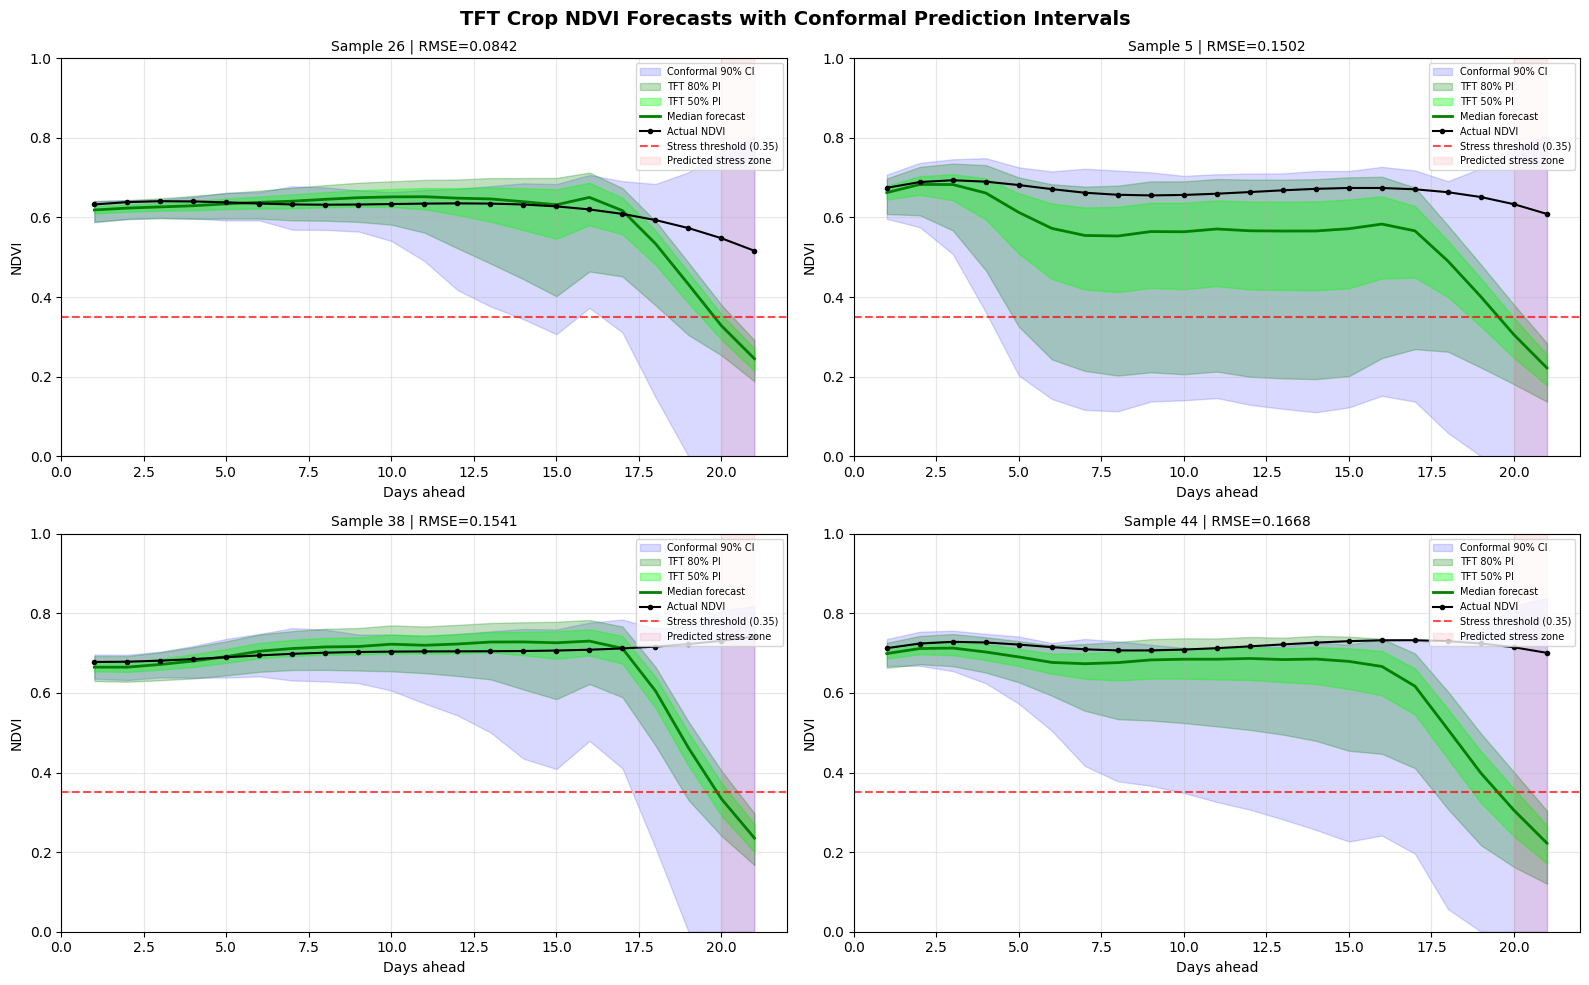

✅ Prediction plots saved

📊 Model Evaluation Metrics
┏━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Metric        ┃   Value ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ RMSE          │  0.1411 │
│ MAE           │  0.0784 │
│ MAPE (%)      │  20.29% │
│ Stress F1     │  0.6667 │
│ Precision     │  1.0000 │
│ Recall        │  0.5000 │
│ Pinball Q0.02 │ 0.00582 │
│ Pinball Q0.1  │ 0.01821 │
│ Pinball Q0.25 │ 0.02992 │
│ Pinball Q0.5  │ 0.03921 │
│ Pinball Q0.75 │ 0.03999 │
│ Pinball Q0.9  │ 0.03550 │
│ Pinball Q0.98 │ 0.02738 │
└───────────────┴─────────┘

In [23]:
def plot_prediction_sample(actuals, preds, cp, n_samples=4):
    """Plot TFT predictions with conformal intervals."""
    quantiles = CFG["quantiles"]
    q_idxs = {q: i for i, q in enumerate(quantiles)}

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle("TFT Crop NDVI Forecasts with Conformal Prediction Intervals",
                 fontsize=14, fontweight="bold")

    rng = np.random.default_rng(42)
    sample_idxs = rng.choice(len(actuals), n_samples, replace=False)

    for i, idx in enumerate(sample_idxs):
        ax = axes[i]
        y    = actuals[idx]
        pred = preds[idx]
        horizon = np.arange(1, len(y) + 1)

        # Quantile bands
        q10 = pred[:, q_idxs[0.1]]
        q25 = pred[:, q_idxs[0.25]]
        q50 = pred[:, q_idxs[0.5]]
        q75 = pred[:, q_idxs[0.75]]
        q90 = pred[:, q_idxs[0.9]]

        # Conformal corrected
        cp_res = cp.predict(pred[:, q_idxs[0.02]],
                            pred[:, q_idxs[0.98]],
                            q50)

        ax.fill_between(horizon, cp_res["lower"], cp_res["upper"],
                        alpha=0.15, color="blue", label="Conformal 90% CI")
        ax.fill_between(horizon, q10, q90,
                        alpha=0.25, color="green", label="TFT 80% PI")
        ax.fill_between(horizon, q25, q75,
                        alpha=0.35, color="lime", label="TFT 50% PI")
        ax.plot(horizon, q50,   "g-",  lw=2,   label="Median forecast")
        ax.plot(horizon, y,     "ko-", lw=1.5, markersize=3, label="Actual NDVI")
        ax.axhline(CFG["stress_threshold"], color="red", ls="--",
                   alpha=0.7, label=f"Stress threshold ({CFG['stress_threshold']})")

        # Shade stress zone
        stress_pred = q50 < CFG["stress_threshold"]
        if stress_pred.any():
            ax.fill_between(horizon, 0, 1,
                            where=stress_pred, alpha=0.08,
                            color="red", label="Predicted stress zone")

        ax.set_title(f"Sample {idx} | RMSE={np.sqrt(np.mean((q50-y)**2)):.4f}", fontsize=10)
        ax.set_xlabel("Days ahead")
        ax.set_ylabel("NDVI")
        ax.legend(fontsize=7, loc="upper right")
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/tft_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    console.print("[green]✅ Prediction plots saved[/green]")


def plot_variable_importance(model, training):
    """TFT built-in interpretability: variable importance."""
    interpretation = model.interpret_output(
        model.predict(val_dl, return_x=True, return_y=True)[1],
        reduction="sum"
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("TFT Variable Importance (Attention-based)", fontsize=13, fontweight="bold")

    def plot_importance(ax, scores, title, color):
        sorted_idx = np.argsort(scores)
        ax.barh(range(len(scores)), scores[sorted_idx], color=color, alpha=0.8)
        ax.set_yticks(range(len(scores)))
        ax.grid(alpha=0.3, axis="x")
        ax.set_title(title, fontweight="bold")

    # Encoder importance
    enc_imp = interpretation["encoder_variables"].cpu().numpy()
    plot_importance(axes[0], enc_imp, "Encoder Variable Importance", "#2196F3")

    # Decoder importance
    dec_imp = interpretation["decoder_variables"].cpu().numpy()
    plot_importance(axes[1], dec_imp, "Decoder Variable Importance", "#4CAF50")

    # Static importance
    stat_imp = interpretation["static_variables"].cpu().numpy()
    plot_importance(axes[2], stat_imp, "Static Variable Importance", "#FF9800")

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/variable_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


def compute_metrics(actuals, preds):
    """Comprehensive evaluation metrics."""
    q50 = preds[:, :, 3]  # median
    rmse = np.sqrt(np.mean((q50 - actuals) ** 2))
    mae  = np.mean(np.abs(q50 - actuals))
    mape = np.mean(np.abs((actuals - q50) / (np.abs(actuals) + 1e-6))) * 100

    # Pinball losses per quantile
    pinball = {}
    for i, q in enumerate(CFG["quantiles"]):
        e = actuals - preds[:, :, i]
        pinball[q] = np.mean(np.maximum(q * e, (q - 1) * e))

    # Stress detection F1
    y_true_stress = (actuals.mean(axis=1) < CFG["stress_threshold"]).astype(int)
    y_pred_stress = (q50.mean(axis=1) < CFG["stress_threshold"]).astype(int)
    from sklearn.metrics import f1_score, precision_score, recall_score
    f1   = f1_score(y_true_stress, y_pred_stress, zero_division=0)
    prec = precision_score(y_true_stress, y_pred_stress, zero_division=0)
    rec  = recall_score(y_true_stress, y_pred_stress, zero_division=0)

    table = Table(title="📊 Model Evaluation Metrics")
    table.add_column("Metric", style="cyan")
    table.add_column("Value", style="bold green", justify="right")

    table.add_row("RMSE",       f"{rmse:.4f}")
    table.add_row("MAE",        f"{mae:.4f}")
    table.add_row("MAPE (%)",   f"{mape:.2f}%")
    table.add_row("Stress F1",  f"{f1:.4f}")
    table.add_row("Precision",  f"{prec:.4f}")
    table.add_row("Recall",     f"{rec:.4f}")
    for q, pb in pinball.items():
        table.add_row(f"Pinball Q{q}", f"{pb:.5f}")

    console.print(table)
    return {"rmse": rmse, "mae": mae, "f1": f1, "pinball": pinball}


plot_prediction_sample(val_actuals, val_preds, cp)
metrics = compute_metrics(val_actuals, val_preds)

In [24]:
import shutil, pickle, json

def save_all_artifacts():
    artifacts = {}

    # 1. Best TFT checkpoint already saved by ModelCheckpoint
    shutil.copy(
        checkpoint.best_model_path,
        f"{CFG['output_dir']}/tft_best.ckpt"
    )
    artifacts["model_path"] = f"{CFG['output_dir']}/tft_best.ckpt"

    # 2. TimeSeriesDataSet parameters
    dataset_params = training.get_parameters()
    with open(f"{CFG['output_dir']}/dataset_params.json", "w") as f:
        # Serialize non-JSON-able items
        safe_params = {k: str(v) for k, v in dataset_params.items()}
        json.dump(safe_params, f, indent=2)
    artifacts["dataset_params"] = f"{CFG['output_dir']}/dataset_params.json"

    # 3. Conformal predictor
    with open(f"{CFG['output_dir']}/conformal.pkl", "wb") as f:
        pickle.dump(cp, f)
    artifacts["conformal_path"] = f"{CFG['output_dir']}/conformal.pkl"

    # 4. Farm metadata
    farm_df.to_csv(f"{CFG['output_dir']}/farm_metadata.csv", index=False)
    artifacts["farm_metadata"] = f"{CFG['output_dir']}/farm_metadata.csv"

    # 5. Config
    with open(f"{CFG['output_dir']}/config.json", "w") as f:
        json.dump(CFG, f, indent=2)

    # 6. Metrics
    with open(f"{CFG['output_dir']}/metrics.json", "w") as f:
        safe_metrics = {k: float(v) for k, v in metrics.items() if k != "pinball"}
        json.dump(safe_metrics, f, indent=2)

    # 7. Training logs
    log_file = Path(csv_logger.log_dir) / "metrics.csv"
    if log_file.exists():
        shutil.copy(str(log_file), f"{CFG['output_dir']}/training_logs.csv")

    console.print("\n[bold green]✅ ALL ARTIFACTS SAVED[/bold green]")
    table = Table(title="Saved Artifacts")
    table.add_column("Artifact")
    table.add_column("Path")
    for k, v in artifacts.items():
        table.add_row(k, v)
    console.print(table)

    return artifacts

saved = save_all_artifacts()

# Final summary
console.print("\n[bold cyan]━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━[/bold cyan]")
console.print("[bold yellow]🌾 Crop EWS Training Complete![/bold yellow]")
console.print(f"  Model: TFT | Params: {n_params:,}")
console.print(f"  Val RMSE: {metrics['rmse']:.4f} | F1: {metrics['f1']:.4f}")
console.print(f"  Conformal α={CFG['conformal_alpha']} → "
              f"≥{(1-CFG['conformal_alpha'])*100:.0f}% coverage guaranteed")
console.print(f"  Artifacts: {CFG['output_dir']}")
console.print("[bold cyan]━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━[/bold cyan]")

✅ ALL ARTIFACTS SAVED

                     Saved Artifacts                      
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Artifact       ┃ Path                                  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ model_path     │ /content/crop_ews/tft_best.ckpt       │
│ dataset_params │ /content/crop_ews/dataset_params.json │
│ conformal_path │ /content/crop_ews/conformal.pkl       │
│ farm_metadata  │ /content/crop_ews/farm_metadata.csv   │
└────────────────┴───────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🌾 Crop EWS Training Complete!

Model: TFT | Params: 1,559,393

Val RMSE: 0.1411 | F1: 0.6667

Conformal α=0.1 → ≥90% coverage guaranteed

Artifacts: /content/crop_ews

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [26]:
import shutil
from google.colab import files
shutil.make_archive("/content/crop_ews", 'zip', "/content/crop_ews")
files.download("/content/crop_ews.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>